In [ ]:
# Import libraries
import pandas as pd

# 1. Load the dataset
# Replace the path if your file is in a different folder
df = pd.read_csv("buchia.csv")

# 2. Print the first few rows
print("First 5 rows of the dataset:")
print(df.head())

# 3. Print column names
print("\nColumn names:")
print(df.columns)

# 4. Print dataset shape
# Shape = (rows, columns)
print("\nDataset shape:")
print(df.shape)

# 5. Identify label column and feature columns
# Usually the label is something like species or location
# We check which columns are numeric

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
non_numeric_columns = df.select_dtypes(exclude=['int64', 'float64']).columns

print("\nNumeric columns (good for PCA):")
print(list(numeric_features))

print("\nNon-numeric columns (likely labels / categories):")
print(list(non_numeric_columns))

# Example assumption:
# If there is a column like "species", that is usually the label
label_column = None
for col in non_numeric_columns:
    if "species" in col.lower():
        label_column = col

print("\nPossible label column:")
print(label_column)

# PCA features should be the numeric columns only
pca_features = df[numeric_features]

print("\nFeatures that will be used for PCA:")
print(pca_features.columns)

First 5 rows of the dataset:
    Location         J         I       Ld        Lv        Wa        Wp  \
0  Taseko BC  17.40690 -11.35860  2.30469  2.003470  1.649000  1.317150   
1  Taseko BC  13.72180  -8.14460  1.39880  0.992295  0.835080  0.723899   
2  Taseko BC  10.31080 -12.20650  2.60316  2.248300  1.709080  1.046780   
3  Taseko BC  12.07540 -10.83030  2.42738  1.763230  1.236510  0.784577   
4  Taseko BC   4.66833  -5.20979  1.54111  1.121260  0.809059  0.559734   

         Dd       Dv        In     Delta  
0  1.203080  3.24611  0.938409  0.145662  
1  0.975138  1.49029  0.588475  0.166572  
2  1.446370  3.33082  0.709000  0.195045  
3  1.507450  2.80939  0.687856  0.160851  
4  0.910708  1.89792  0.487325  0.110510  

Column names:
Index(['Location', 'J', 'I', 'Ld', 'Lv', 'Wa', 'Wp', 'Dd', 'Dv', 'In',
       'Delta'],
      dtype='object')

Dataset shape:
(1523, 11)

Numeric columns (good for PCA):
['J', 'I', 'Ld', 'Lv', 'Wa', 'Wp', 'Dd', 'Dv', 'In', 'Delta']

Non-numeric co

In [ ]:
# Check number of missing values in each column
print(df.isnull().sum())

Location    0
J           0
I           0
Ld          0
Lv          0
Wa          0
Wp          0
Dd          0
Dv          0
In          0
Delta       0
dtype: int64


In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
df = pd.read_csv("buchia.csv")

# 2. Keep Location as labels only
# We will use this later for coloring/grouping points in plots
labels = df["Location"]

# 3. Create feature matrix using only numeric morphology variables
# These are the columns used for PCA
feature_cols = ["J", "I", "Ld", "Lv", "Wa", "Wp", "Dd", "Dv", "In", "Delta"]
X = df[feature_cols]

# 4. Standardize the numeric variables
# This changes each column to have mean = 0 and standard deviation = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Print checks
print("Labels (first 5):")
print(labels.head())

print("\nFeature matrix (first 5 rows):")
print(X.head())

print("\nStandardized feature matrix (first 5 rows):")
print(X_scaled[:5])

print("\nShape of feature matrix:")
print(X.shape)

print("\nShape of standardized feature matrix:")
print(X_scaled.shape)

Labels (first 5):
0    Taseko BC
1    Taseko BC
2    Taseko BC
3    Taseko BC
4    Taseko BC
Name: Location, dtype: object

Feature matrix (first 5 rows):
          J         I       Ld        Lv        Wa        Wp        Dd  \
0  17.40690 -11.35860  2.30469  2.003470  1.649000  1.317150  1.203080   
1  13.72180  -8.14460  1.39880  0.992295  0.835080  0.723899  0.975138   
2  10.31080 -12.20650  2.60316  2.248300  1.709080  1.046780  1.446370   
3  12.07540 -10.83030  2.42738  1.763230  1.236510  0.784577  1.507450   
4   4.66833  -5.20979  1.54111  1.121260  0.809059  0.559734  0.910708   

        Dv        In     Delta  
0  3.24611  0.938409  0.145662  
1  1.49029  0.588475  0.166572  
2  3.33082  0.709000  0.195045  
3  2.80939  0.687856  0.160851  
4  1.89792  0.487325  0.110510  

Standardized feature matrix (first 5 rows):
[[ 1.53178611 -1.31582031  0.29122313  1.06689385  0.74950929  0.48460619
  -0.25977469  1.17360708 -0.28430558 -0.41483638]
 [ 1.15879592 -0.93234823 -0.865

In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load the dataset
df = pd.read_csv("buchia.csv")

# 2. Keep Location as labels only
labels = df["Location"]

# 3. Select only the numeric morphology variables for PCA
feature_cols = ["J", "I", "Ld", "Lv", "Wa", "Wp", "Dd", "Dv", "In", "Delta"]
X = df[feature_cols]

# 4. Standardize the numeric variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Fit PCA on the standardized data
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 6. Calculate eigenvalues
# These show how much variance each principal component captures
eigenvalues = pca.explained_variance_

# 7. Calculate explained variance ratios
# These are proportions (for example 0.25 = 25%)
explained_variance_ratios = pca.explained_variance_ratio_

# 8. Calculate percent variation explained
percent_variation = explained_variance_ratios * 100

# 9. Print eigenvalues
print("Eigenvalues:")
for i, value in enumerate(eigenvalues, start=1):
    print(f"PC{i}: {value:.4f}")

# 10. Print explained variance ratios
print("\nExplained variance ratios:")
for i, value in enumerate(explained_variance_ratios, start=1):
    print(f"PC{i}: {value:.4f}")

# 11. Print percent variation explained
print("\nPercent variation explained by each principal component:")
for i, value in enumerate(percent_variation, start=1):
    print(f"PC{i}: {value:.2f}%")

# 12. Print the first three principal components clearly
print("\nFirst three principal components (scores for each sample):")
pc_df = pd.DataFrame(
    X_pca[:, :3],
    columns=["PC1", "PC2", "PC3"]
)

print(pc_df.head())

# Optional: include Location labels with the first three PCs
print("\nFirst three principal components with Location labels:")
pc_with_labels = pd.concat([labels.reset_index(drop=True), pc_df], axis=1)
print(pc_with_labels.head())

Eigenvalues:
PC1: 6.6538
PC2: 1.8284
PC3: 0.6137
PC4: 0.2352
PC5: 0.1841
PC6: 0.1720
PC7: 0.1228
PC8: 0.1113
PC9: 0.0510
PC10: 0.0343

Explained variance ratios:
PC1: 0.6649
PC2: 0.1827
PC3: 0.0613
PC4: 0.0235
PC5: 0.0184
PC6: 0.0172
PC7: 0.0123
PC8: 0.0111
PC9: 0.0051
PC10: 0.0034

Percent variation explained by each principal component:
PC1: 66.49%
PC2: 18.27%
PC3: 6.13%
PC4: 2.35%
PC5: 1.84%
PC6: 1.72%
PC7: 1.23%
PC8: 1.11%
PC9: 0.51%
PC10: 0.34%

First three principal components (scores for each sample):
        PC1       PC2       PC3
0  0.966832  2.327987 -0.267169
1 -2.201165  1.265319  0.562004
2  1.310581  1.876949  0.245869
3  0.070276  1.698859  0.079991
4 -2.256340  0.548878 -0.177291

First three principal components with Location labels:
    Location       PC1       PC2       PC3
0  Taseko BC  0.966832  2.327987 -0.267169
1  Taseko BC -2.201165  1.265319  0.562004
2  Taseko BC  1.310581  1.876949  0.245869
3  Taseko BC  0.070276  1.698859  0.079991
4  Taseko BC -2.256340 

In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv("buchia.csv")

# 2. Select numeric morphology variables
feature_cols = ["J", "I", "Ld", "Lv", "Wa", "Wp", "Dd", "Dv", "In", "Delta"]
X = df[feature_cols]

# 3. Standardize the variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 5. Calculate percent variation explained
variance_ratios = pca.explained_variance_ratio_ * 100

# 6. Print percent variation explained by first three PCs
print("Percent of total variation explained:")
print(f"PC1: {variance_ratios[0]:.2f}%")
print(f"PC2: {variance_ratios[1]:.2f}%")
print(f"PC3: {variance_ratios[2]:.2f}%")

Percent of total variation explained:
PC1: 66.49%
PC2: 18.27%
PC3: 6.13%


In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv("buchia.csv")

# 2. Select numeric morphology variables
feature_cols = ["J", "I", "Ld", "Lv", "Wa", "Wp", "Dd", "Dv", "In", "Delta"]
X = df[feature_cols]

# 3. Standardize the variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Perform PCA
pca = PCA()
pca.fit(X_scaled)

# 5. Get PC1 loadings
pc1_loadings = pca.components_[0]

# 6. Print loadings matched with variable names
print("PC1 Loadings (Variable : Loading value)")
for variable, loading in zip(feature_cols, pc1_loadings):
    print(f"{variable}: {loading:.4f}")

PC1 Loadings (Variable : Loading value)
J: -0.0337
I: 0.0475
Ld: 0.3738
Lv: 0.3674
Wa: 0.3692
Wp: 0.3594
Dd: 0.3633
Dv: 0.3657
In: 0.3580
Delta: 0.2502


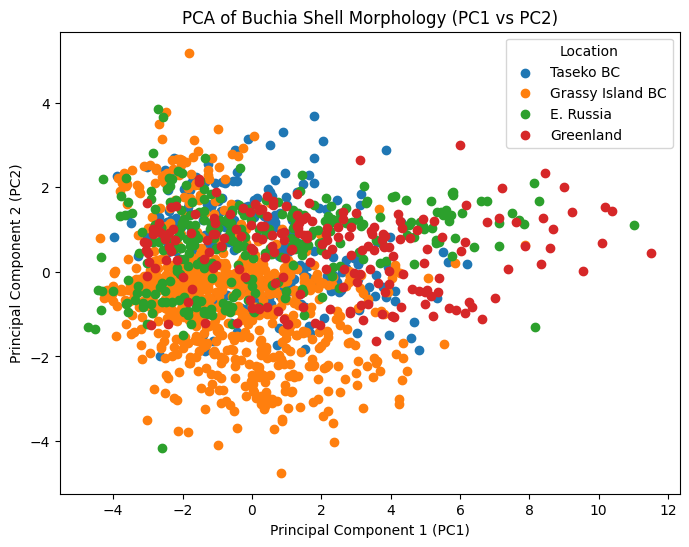

In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("buchia.csv")

# 2. Keep Location for colouring only
labels = df["Location"]

# 3. Select only numeric morphology variables for PCA
feature_cols = ["J", "I", "Ld", "Lv", "Wa", "Wp", "Dd", "Dv", "In", "Delta"]
X = df[feature_cols]

# 4. Standardize the variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 6. Create DataFrame with PCA results
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Location"] = labels

# 7. Create scatter plot
plt.figure(figsize=(8,6))

# Plot points grouped by Location
for location in pca_df["Location"].unique():
    subset = pca_df[pca_df["Location"] == location]
    plt.scatter(subset["PC1"], subset["PC2"], label=location)

# 8. Label axes
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

# 9. Add title
plt.title("PCA of Buchia Shell Morphology (PC1 vs PC2)")

# 10. Add legend
plt.legend(title="Location")

# 11. Save plot as PNG
plt.savefig("buchia_pca_PC1_PC2.png")

# 12. Show plot
plt.show()

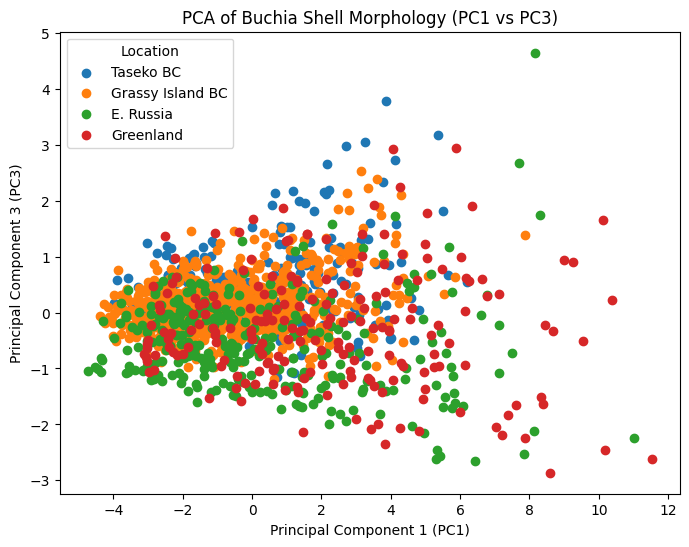

In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("buchia.csv")

# 2. Keep Location for colouring only
labels = df["Location"]

# 3. Select numeric morphology variables for PCA
feature_cols = ["J", "I", "Ld", "Lv", "Wa", "Wp", "Dd", "Dv", "In", "Delta"]
X = df[feature_cols]

# 4. Standardize variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Perform PCA (at least 3 components needed)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 6. Create DataFrame with PCA results
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
pca_df["Location"] = labels

# 7. Create scatter plot PC1 vs PC3
plt.figure(figsize=(8,6))

# Plot points for each location
for location in pca_df["Location"].unique():
    subset = pca_df[pca_df["Location"] == location]
    plt.scatter(subset["PC1"], subset["PC3"], label=location)

# 8. Label axes
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 3 (PC3)")

# 9. Add title
plt.title("PCA of Buchia Shell Morphology (PC1 vs PC3)")

# 10. Add legend
plt.legend(title="Location")

# 11. Save the plot
plt.savefig("buchia_pca_PC1_PC3.png")

# 12. Show the plot
plt.show()

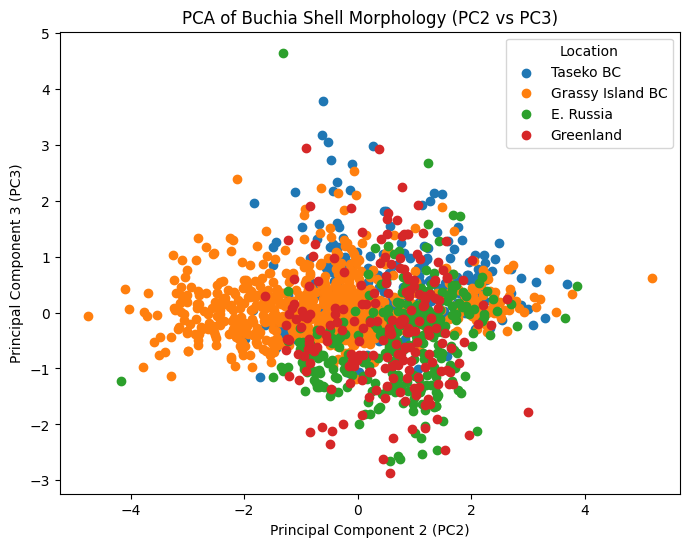

In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("buchia.csv")

# 2. Keep Location only for colouring the points
labels = df["Location"]

# 3. Select numeric morphology variables for PCA
feature_cols = ["J", "I", "Ld", "Lv", "Wa", "Wp", "Dd", "Dv", "In", "Delta"]
X = df[feature_cols]

# 4. Standardize the variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Perform PCA (need at least 3 components)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 6. Store PCA results in a dataframe
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
pca_df["Location"] = labels

# 7. Create scatter plot PC2 vs PC3
plt.figure(figsize=(8,6))

# Plot each location with different colour
for location in pca_df["Location"].unique():
    subset = pca_df[pca_df["Location"] == location]
    plt.scatter(subset["PC2"], subset["PC3"], label=location)

# 8. Label axes
plt.xlabel("Principal Component 2 (PC2)")
plt.ylabel("Principal Component 3 (PC3)")

# 9. Add title
plt.title("PCA of Buchia Shell Morphology (PC2 vs PC3)")

# 10. Add legend
plt.legend(title="Location")

# 11. Save plot as PNG
plt.savefig("buchia_pca_PC2_PC3.png")

# 12. Show the plot
plt.show()

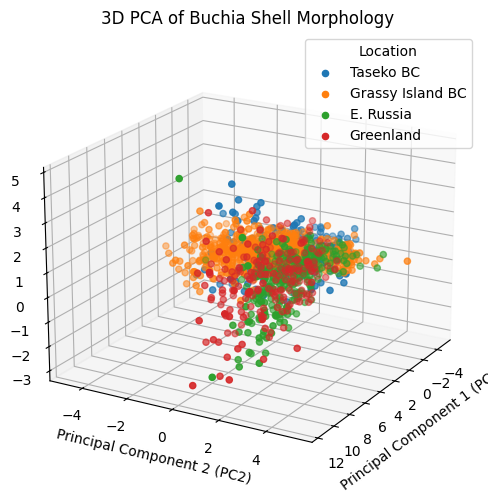

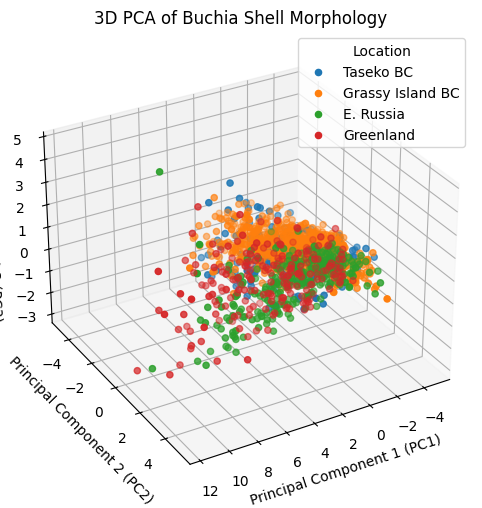

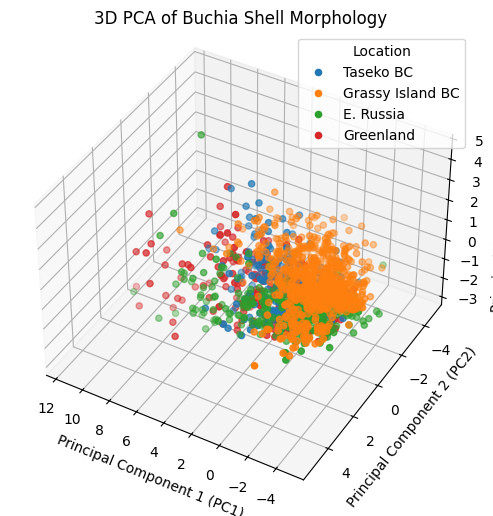

In [ ]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Load dataset
df = pd.read_csv("buchia.csv")

# 2. Keep Location for colouring only
labels = df["Location"]

# 3. Select numeric morphology variables
feature_cols = ["J", "I", "Ld", "Lv", "Wa", "Wp", "Dd", "Dv", "In", "Delta"]
X = df[feature_cols]

# 4. Standardize the variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Perform PCA (3 components)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 6. Create DataFrame with PCA results
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
pca_df["Location"] = labels

# 7. Unique locations for colouring
locations = pca_df["Location"].unique()

# 8. Viewing angles to generate multiple plots
angles = [(20,30), (30,60), (40,120)]

# 9. Create plots for each viewing angle
for i, (elev, azim) in enumerate(angles):

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    # Plot points by location
    for location in locations:
        subset = pca_df[pca_df["Location"] == location]
        ax.scatter(subset["PC1"], subset["PC2"], subset["PC3"], label=location)

    # Label axes
    ax.set_xlabel("Principal Component 1 (PC1)")
    ax.set_ylabel("Principal Component 2 (PC2)")
    ax.set_zlabel("Principal Component 3 (PC3)")

    # Title
    ax.set_title("3D PCA of Buchia Shell Morphology")

    # Legend
    ax.legend(title="Location")

    # Set viewing angle
    ax.view_init(elev=elev, azim=azim)

    # Save each view
    filename = f"buchia_pca_3D_view_{i+1}.png"
    plt.savefig(filename)

    plt.show()